## Predicting the NBA Finals MVP with ML
#### *by Noah Ford*


#### Importing Packages and Helper Functions

I've outsourced most of the importing of tools and helper functions of an accompanying workbook [helper_funcs.ipynb](helper_funcs.ipynb).

In [2]:
%run helper_funcs.ipynb
print('success!')

success!


#### Getting Set Up

Here we'll set up the paths to the data we will access throughout.

In [3]:
DIR = 'series'
DIR2 = 'csvs'

The first jumping off point for this notebook, is getting access to the playoff history.  We will use [basketball-reference.com](https://www.basketball-reference.com) for the entirety of our data accessing. \
This first link we're accessing takes us to a page with information for every playoff series: winner, loser, finals mvp, hyperlinks to more stats, etc.

## Data Scraping

In [4]:
BASE = "https://www.basketball-reference.com"
url = "https://www.basketball-reference.com/playoffs/series.html"
# save takes a path and a folder, and fetches the html we're looking for
text = save(url,DIR)
bs = BeautifulSoup(text, 'html.parser')
table = bs.find(id = 'div_playoffs_series')

This below function wraps up that above code into a nice callable unit.

In [5]:
def get_html_table():
    url = "https://www.basketball-reference.com/playoffs/series.html"
    text = save(url,DIR)
    bs = BeautifulSoup(text, 'html.parser')
    table = bs.find(id = 'div_playoffs_series')
    return table

playoff_history just is a wrapper for the pandas native function read_html, which when given html, spits out a dataframe.

In [6]:
def playoff_history(url,header_col=False):
    p = os.path.join(DIR2, name_csv(url))
    if not(os.path.exists(p)):
        text = save(url,DIR2)
        bs = BeautifulSoup(text, 'html.parser')
        df = pd.read_html(url)[0]
        if header_col: df.columns = df.columns.get_level_values(1)
        df.to_csv(p,index=True)
    else :
        df = pd.read_csv(p,index_col=0)
    return df

In [7]:
url = "https://www.basketball-reference.com/playoffs/series.html"
t = playoff_history(url,True)

We'll just do a bit of cleaning to drop some unneeded columns.  Additionally, we only care about finals history.

In [8]:
def playoff_history_cleaned():
    url = "https://www.basketball-reference.com/playoffs/series.html"
    df = playoff_history(url,True)
    df.drop(df.columns[[4,7,10,-2,-1]], axis=1, inplace=True)
    df['Yr'] = pd.to_numeric(df['Yr'], errors='coerce').fillna(0).astype(int)
    df = df[df['Lg'].str.contains('NBA', na=False)].reset_index(drop=True)
    df = df[df['Yr']>1968].reset_index(drop=True)
    df = df[~df['Series'].str.contains('Conf', na=True)].reset_index(drop=True)
    df = df[~df['Series'].str.contains('Semi', na=False)].reset_index(drop=True)
    df = df[~df['Series'].str.contains('Div', na=False)].reset_index(drop=True)
    return df 

In [9]:
playoff_history_cleaned().head(5)

,Yr,Lg,Series,Unnamed: 3_level_1,Team,W,Team.1,W.1
0,2024,NBA,Finals,"Jun 6 - Jun 17, 2024",Boston Celtics (1),4,Dallas Mavericks (5),1
1,2023,NBA,Finals,"Jun 1 - Jun 12, 2023",Denver Nuggets (1),4,Miami Heat (8),1
2,2022,NBA,Finals,"Jun 2 - Jun 16, 2022",Golden State Warriors (3),4,Boston Celtics (2),2
3,2021,NBA,Finals,"Jul 6 - Jul 20, 2021",Milwaukee Bucks (3),4,Phoenix Suns (2),2
4,2020,NBA,Finals,"Sep 30 - Oct 11, 2020",Los Angeles Lakers (1),4,Miami Heat (5),2


I've stored the finals MVP history into an existing csv, so we can actually look at that using our same playoff_history function, just passing that different file path.

In [10]:
url = 'https://www.basketball-reference.com/awards/finals_mvp.html'
df = playoff_history('csvs/finals_mvp.csv',True)
df.head(5)

,Season,Lg,Player,Age,Tm,G,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%
0,2023-24,NBA,Jaylen Brown,27,BOS,5,38.6,20.8,5.4,5.0,1.6,0.8,0.440,0.235,0.733
1,2022-23,NBA,Nikola Jokic,27,DEN,5,41.2,30.2,14.0,7.2,0.8,1.4,0.583,0.421,0.838
2,2021-22,NBA,Stephen Curry,33,GSW,6,37.5,31.2,6.0,5.0,2.0,0.2,0.482,0.437,0.857
3,2020-21,NBA,Giannis Antetokounmpo,26,MIL,6,39.8,35.2,13.2,5.0,1.2,1.8,0.618,0.200,0.659
4,2019-20,NBA,LeBron James,35,LAL,6,39.3,29.8,11.8,8.5,1.2,0.5,0.591,0.417,0.667


Now we would like to merge the finals history dataframe, the finals mvp dataframe, and a dataframe of hyperlinks into the series summary of each dataframe.

That last one is the trickiest to get because the links do not populate in the finals history dataframe from our read_html call.  So, we have to perform a workaround to read through the html directly.

In [11]:
def add_mvp():
    df = pd.read_csv('csvs/finals_mvp.csv',index_col=0)
    return df

In [12]:
def hyperlink_table():
    table = get_html_table()
    series = [tag for tag in table.find_all('a') if "vs" in tag['href']]
    recent = [tag for tag in series if int(tag['href'].split("/")[2].split("-")[0]) > 1968]
    hrefs = [BASE + a['href'] for a in recent]
    col = [tag for tag in hrefs if 'nba-finals' in tag]
    col = pd.DataFrame(col, columns=["url"])
    return col

In [13]:
def merged_table():
    # ret = await get_html(url,"#div_playoffs_series")
    table = get_html_table()
    df = playoff_history_cleaned()
    col = hyperlink_table()
    full = pd.concat([df,add_mvp()],axis = 1)
    full = pd.concat([full,col],axis = 1)
    return full

In [14]:
FULL_DF = merged_table()
FULL_DF.head(5)

,Yr,Lg,Series,Unnamed: 3_level_1,Team,W,Team.1,W.1,Season,Lg,...,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%,url
0,2024,NBA,Finals,"Jun 6 - Jun 17, 2024",Boston Celtics (1),4,Dallas Mavericks (5),1,2023-24,NBA,...,38.6,20.8,5.4,5.0,1.6,0.8,0.440,0.235,0.733,https://www.basketball-reference.com/playoffs/...
1,2023,NBA,Finals,"Jun 1 - Jun 12, 2023",Denver Nuggets (1),4,Miami Heat (8),1,2022-23,NBA,...,41.2,30.2,14.0,7.2,0.8,1.4,0.583,0.421,0.838,https://www.basketball-reference.com/playoffs/...
2,2022,NBA,Finals,"Jun 2 - Jun 16, 2022",Golden State Warriors (3),4,Boston Celtics (2),2,2021-22,NBA,...,37.5,31.2,6.0,5.0,2.0,0.2,0.482,0.437,0.857,https://www.basketball-reference.com/playoffs/...
3,2021,NBA,Finals,"Jul 6 - Jul 20, 2021",Milwaukee Bucks (3),4,Phoenix Suns (2),2,2020-21,NBA,...,39.8,35.2,13.2,5.0,1.2,1.8,0.618,0.200,0.659,https://www.basketball-reference.com/playoffs/...
4,2020,NBA,Finals,"Sep 30 - Oct 11, 2020",Los Angeles Lakers (1),4,Miami Heat (5),2,2019-20,NBA,...,39.3,29.8,11.8,8.5,1.2,0.5,0.591,0.417,0.667,https://www.basketball-reference.com/playoffs/...


In [15]:
def winner_abbrev(url):
    bs = BeautifulSoup(save(url,DIR))
    ref = [link['href'] for link in bs.find_all('a') if 'teams' in link['href'] and '.html' in link['href']][0]
    return ref.split('/')[2]

In [16]:
winner_abbrev(FULL_DF['url'][0])

'BOS'

We enter into some dicey territory here because for some reason, basketball reference was keeping their accessible playoff series stats only in the form of a comment.  Meaning, we have to convert the comment into usable html before we can proceed.

The reason we wrote the winner_abbrev functions above is because the boxscores are ordered not by who won, but rather who was home.  Meaning, when we're searching the page, we have to introduce logic to jump to the correct box score.  We achieve that here by pulling the abbreviation of each team, which is then used to label the box scores in the id.

In [17]:
def save_table(url):
    p = os.path.join(DIR2, name_csv(url))
    if not(os.path.exists(p)):
        save_tag(url,DIR,f'all_{winner_abbrev(url)}')
        text = save_tag(url,DIR,f'all_{winner_abbrev(url)}')
        bs = BeautifulSoup(text, 'html.parser')
        # table = bs.find(id = f'div_{winner_abbrev(url)}')
        # Find all comments
        comments = bs.find_all(string=lambda text: isinstance(text, Comment))
        table_c = [c for c in comments if len(c) > 10000][0]
        comment_soup = BeautifulSoup(table_c, 'html.parser')
        table = comment_soup.find('table')
        df = pd.read_html(str(table))[0]
        df.columns = df.columns.get_level_values(1)
        df.drop(df.columns[[0]], axis=1, inplace=True)
        df.to_csv(p)
        with open(p, "w+") as f:
            f.write(df.to_csv(p))
    else :
        df = pd.read_csv(p)
        df.drop(df.columns[[0]], axis=1, inplace=True)
    return df

Here I want to optimize the retrieval of our html information, so I'll plop that all into csvs which will be easier to access than the htmls.

In [18]:
def get_table(url):
    p = os.path.join(DIR2, name_csv(url))
    df = pd.read_csv(p)
    df.drop(df.columns[[0]], axis=1, inplace=True)
    return df

In [19]:
for link in tqdm(FULL_DF['url']):
    try:
        save_table(link)
    except:
        save_table(link)

100%|██████████| 56/56 [00:00<00:00, 1048.20it/s]


In [20]:
url = FULL_DF['url'][2]
get_table(url).head(5)

,Player,Age,G,MP,FG,FGA,3P,3PA,FT,FTA,...,PTS,FG%,3P%,FT%,MP.1,PTS.1,TRB.1,AST.1,STL.1,BLK.1
0,Stephen Curry,33.0,6,225,66,137,31,71,24,28,...,187,0.482,0.437,0.857,37.5,31.2,6.0,5.0,2.0,0.2
1,Andrew Wiggins,26.0,6,235,45,101,11,37,9,13,...,110,0.446,0.297,0.692,39.2,18.3,8.8,2.2,1.5,1.5
2,Klay Thompson,31.0,6,230,36,101,20,57,10,10,...,102,0.356,0.351,1.000,38.3,17.0,3.0,2.0,1.3,0.5
3,Jordan Poole,22.0,6,125,27,62,15,39,10,11,...,79,0.435,0.385,0.909,20.8,13.2,1.8,1.8,0.5,0.2
4,Draymond Green,31.0,6,217,14,42,2,16,7,12,...,37,0.333,0.125,0.583,36.2,6.2,8.0,6.2,1.7,0.7


## Data Cleaning

Now we're almost there!  We now just need to clean up our data to make nice integers and floats for the machine learning models to read.

In [21]:
def clean_table(url):
    t = get_table(url)
    mvp = mvp_from_url(url)
    t.drop(t.columns[[1,5,7,9,-6,-5,-4,-3,-2,-1]], axis=1, inplace=True)
    t = t.drop(t.index[-1])
    yr = year_from_url(url)
    t['3P'] = pd.to_numeric(t['3P'], errors='coerce').fillna(0).astype(int)
    t['FG%'] = pd.to_numeric(t['FG%'], errors='coerce').fillna(0).astype(float)
    t['3P%'] = pd.to_numeric(t['3P%'], errors='coerce').fillna(0).astype(float)
    t['FT%'] = pd.to_numeric(t['FT%'], errors='coerce').fillna(0).astype(float)
    t['STL'] = pd.to_numeric(t['STL'], errors='coerce').fillna(0).astype(int)
    t['BLK'] = pd.to_numeric(t['BLK'], errors='coerce').fillna(0).astype(int)
    t['ORB'] = pd.to_numeric(t['ORB'], errors='coerce').fillna(0).astype(int)
    t['DRB'] = pd.to_numeric(t['DRB'], errors='coerce').fillna(0).astype(int)
    t['TOV'] = pd.to_numeric(t['TOV'], errors='coerce').fillna(0).astype(int)
    # t['Age'] = pd.to_numeric(t['Age'], errors='coerce').fillna(0).astype(int)
    t['mvp'] = t['Player'].apply(lambda x: x == mvp)
    return t

A big picture ML decision I've made on this project is to label players statistics by their relative rank to their teammates.  Meaning, I'm not interested in knowing that player X who put a 30/6/5 should win MVP, because if that player had a teammate who put up 35/12/9, then we'd have to reconsider. \
However, that is a potential follow up of this project.

In [22]:
def rank_table(t):
    # MP through blocks
    cols = t.columns[1:18]
    for i,col in enumerate(cols):
        new_name = col + '!'
        ascending_bool = (i == 11) or (i == 12)
        t[new_name] = t[col].rank(ascending=ascending_bool, method='min').astype(int)
        t.drop(columns = [col],inplace=True)
    return t

top_table takes just the top X entries from the table.  Meaning we don't care to predict Brian Scalabrine's chance at winning MVP.

In [23]:
def top_table(url,top=8,rank=True):
    df = clean_table(url)
    df = df.drop(df.index[top:])
    if rank: 
        df = rank_table(df)
    yr = year_from_url(url)
    df.insert(0,'Year',yr)
    return df

We'll try to pull a random year's url, to see what that table looks like.

In [24]:
top_table(FULL_DF['url'][55],8)

,Year,Player,mvp,G!,MP!,FG!,3P!,FT!,ORB!,DRB!,TRB!,AST!,STL!,BLK!,TOV!,PF!,PTS!,FG%!,3P%!,FT%!
0,1969,John Havlicek,False,1,1,1,1,1,1,1,2,2,1,1,1,4,1,3,1,4
1,1969,Sam Jones,False,1,4,2,1,3,1,1,6,5,1,1,1,2,2,1,1,5
2,1969,Larry Siegfried,False,1,6,3,1,2,1,1,7,3,1,1,1,7,3,7,1,2
3,1969,Don Nelson,False,1,7,4,1,3,1,1,3,6,1,1,1,3,4,4,1,6
4,1969,Em Bryant,False,1,3,5,1,5,1,1,5,4,1,1,1,5,5,5,1,3
5,1969,Bailey Howell,False,1,5,5,1,7,1,1,4,7,1,1,1,8,6,8,1,7
6,1969,Bill Russell,False,1,1,7,1,6,1,1,1,1,1,1,1,6,7,6,1,8
7,1969,Tom Sanders,False,8,8,8,1,8,1,1,8,8,1,1,1,1,8,2,1,1


Here will be the dataframe we will base our learning upon.  It is the top eight highest scoring players of each winning NBA champion.

In [25]:
def build_table(tableName,rank=True):
    table = top_table(FULL_DF['url'][0],8,rank)
    for i in tqdm(range(len(FULL_DF['url'])-1)):
        table = pd.concat([table,top_table(FULL_DF['url'][i+1],8,rank)],axis=0)
    table.reset_index(drop=True).to_csv(f'output/{tableName.lower()}.csv')
    return table.reset_index(drop=True)

In [26]:
FULL_TOP_8 = build_table('FULL_TOP_8',True)
FULL_TOP_8_unranked = build_table('FULL_TOP_8_unranked',False)

100%|██████████| 55/55 [00:00<00:00, 309.92it/s]


In [27]:
FULL_TOP_8.sample(5)

,Year,Player,mvp,G!,MP!,FG!,3P!,FT!,ORB!,DRB!,TRB!,AST!,STL!,BLK!,TOV!,PF!,PTS!,FG%!,3P%!,FT%!
384,1976,Jo Jo White,True,1,1,2,1,1,6,3,5,1,2,6,1,5,1,4,1,3
221,1997,Ron Harper,False,1,4,6,5,5,5,4,4,4,3,2,1,4,6,7,4,5
70,2016,Iman Shumpert,False,1,7,7,5,8,6,7,7,8,7,4,4,2,7,7,4,1
33,2020,Anthony Davis,False,1,2,2,6,1,1,2,2,3,1,1,7,8,2,2,1,2
72,2015,Stephen Curry,False,1,1,1,1,2,5,3,4,1,2,7,8,4,1,5,4,3


## Machine Learning

Ok, now we get into the ML classification.

We will working with the scikit_learn infrastructure to perform our analysis.

### Quick and Dirty


First, do we even need machine learning to answer this question?

To benchmark the success of our machine learning model, we would like a control to compare our results against.  There is one intuitive control, and one more closely replicating our process.

The first would simply be, is the MVP the player who totalled the most combined points, rebounds, and assists.  Now, while it's intuitive, it's answering a slightly different question.  \
\
The question it is answering is "who should have won Finals MVP among these players?" which is certainly a valid question.  But from the way we have framed our data, we are answering the question, given player X's performance relative to all players in set Y, how deserving is player X to win Finals MVP?

In [28]:
def just_points(url):
    df = clean_table(url)
    player_max = df['PTS'].idxmax()
    return df.loc[player_max, 'Player']

In [29]:
def points_rebounds_assists(url):
    df = clean_table(url)
    df['dirty'] = df.apply(lambda row: row['PTS']+row['TRB']+row['AST'], axis=1)
    player_max = df['dirty'].idxmax()
    return df.loc[player_max, 'Player']

In [30]:
def control_trial(dirty_method):
    y_pred = merged_table()['url'].apply(lambda x: dirty_method(x))
    y_true = merged_table()[:-1][['Yr','Team','Player']]
    y_true = y_true.rename(columns={'Yr': 'Year'})
    y_true['Team'] = y_true['Team'].apply(lambda x: x[:x.find(" (")])
    y_true['Guess'] = y_pred
    y_true['Correct'] = y_true['Player'] == y_true['Guess']
    return y_true

In [31]:
just_points_output = control_trial(just_points)
ppg_trb_ast_output = control_trial(points_rebounds_assists)
ppg_trb_ast_output.head(5)

,Year,Team,Player,Guess,Correct
0,2024,Boston Celtics,Jaylen Brown,Jayson Tatum,False
1,2023,Denver Nuggets,Nikola Jokic,Nikola Jokic,True
2,2022,Golden State Warriors,Stephen Curry,Stephen Curry,True
3,2021,Milwaukee Bucks,Giannis Antetokounmpo,Giannis Antetokounmpo,True
4,2020,Los Angeles Lakers,LeBron James,LeBron James,True


So how did we do? -- Let's take a look.

In [32]:
print("Just points:")
print(just_points_output['Correct'].describe())
print("\nPoints, rebounds, assists:")
print(ppg_trb_ast_output['Correct'].describe())

Just points:
count       55
unique       2
top       True
freq        43
Name: Correct, dtype: object

Points, rebounds, assists:
count       55
unique       2
top       True
freq        41
Name: Correct, dtype: object


So we have got 41 and 43 respectively out of 55.  That's not horrible, but promising that we can hope to do better.  Funny that more information led us further from the truth.

In [33]:
print(round(41/55,2))
print(round(43/55,2))

0.75
0.78


### Logistic Regression

The meat of this notebook... hopefully.

A reminder that FULL_TOP_8 is our global variable (I know) dataframe that we can reference to keep a nice storage of the top 8 scoring players of each team.

First we split the dataset into data to learn on, and the data label itself.

In [34]:
X = FULL_TOP_8.drop(['Year','Player','mvp'],axis=1)
y = FULL_TOP_8['mvp']

Now we split the data into 70% being training data, and 30% being testing.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, 

                                           stratify = y, random_state=2022)
smote = SMOTE(sampling_strategy='minority')
X_train_SMOTE, y_train_SMOTE = smote.fit_resample(X_train,y_train)

You might notice "SMOTE".  And you might ask, what is that?  Well "synthetic minority oversampling technique".  Think affirmative action.  I'm just joking.  Basically in our dataset, because we're trying to label the MVP, and there is only one MVP awarded each season to a roster of 15 or so players (here we cut down to 8 players to remedy a bit), it follows that in our case that only about 12% of the data will be labeled "MVP". \
\
This is a bit of a problem because our model will be much more comfortable assigning the "non-mvp" label, simply because it's more used to doing so, and being rewarded for doing so. \
\
Enter SMOTE.  For each Finals MVP, say Lebron James it looks at its nearest similar neighbors (stat wise), say Larry Bird, and Ervin Magic Johnson are two, and creates datapoints in between these players.  Say the fake data points would then be named "Larry Magic James" or "Lebron Johnson", etc. with corresponding averaged stats.

Notice how we are able to train train on significantly more "True" Finals_MVP cases with our SMOTE implementation.

In [36]:
pd.DataFrame(y_test).value_counts()

mvp  
False    118
True      17
dtype: int64

In [37]:
y_train_SMOTE.value_counts()

False    275
True     275
Name: mvp, dtype: int64

Ok, now for K-Fold.  If you're unfamiliar, basically we want to label every point with a prediction.  But because we train on a portion of our data, and then only make predictions on a smaller test set, we're stuck a bit.  Enter K-Fold. \
\
If your testing size is set to 20% of your entire dataset, K Fold then goes through 1/.20, so 5 iterations of splitting into testing and training, ensuring each data point is included in the test set once. \
\
I didn't invent it, but I'm happy to take credit.

In [38]:
logistic_classifier = LogisticRegression(max_iter=200)
smote = SMOTE(sampling_strategy='minority')
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
# just book-keeping how we collect results
oof_predictions = np.zeros((X.shape[0], 2))
oof_binary = np.zeros(X.shape[0])

# ACTUAL MACHINE LEARNING
# test_index is jumping from first 20%, to then 20% through 40%, etc.
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Apply SMOTE to the training data
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    # Train the model on the balanced data
    logistic_classifier.fit(X_train_res, y_train_res)
    
    # Predict probabilities for the validation set
    oof_predictions[test_index] = logistic_classifier.predict_proba(X_test)
    oof_binary[test_index] = y_test

# more book-keeping
oof_df = pd.DataFrame(oof_predictions[:,1], columns=['prob_mvp']).round(2)
output = pd.concat([FULL_TOP_8[['Year','Player','mvp']].reset_index(drop=True), oof_df], axis=1)
final_predictions = oof_predictions[:,1].round(0)
output['Binary'] = final_predictions
output['Correct'] = final_predictions == output['mvp']
mvp_col = output['Year'].apply(mvp_from_year)
output.insert(loc=1,column='MVP',value=mvp_col)
team_col = output['Year'].apply(champ_from_year)
output.insert(loc=1,column='Team',value=team_col)
rank_col = output.groupby(['Year', 'Team'])['prob_mvp'].rank(ascending=False, method='dense').astype(int)
output.insert(loc=6,column='Rank',value=rank_col)
output.to_csv('output/machine_learning_output.csv')
output.head(5)

,Year,Team,MVP,Player,mvp,prob_mvp,Rank,Binary,Correct
0,2024,Boston Celtics,Jaylen Brown,Jayson Tatum,False,0.87,1,1.0,False
1,2024,Boston Celtics,Jaylen Brown,Jaylen Brown,True,0.01,3,0.0,False
2,2024,Boston Celtics,Jaylen Brown,Jrue Holiday,False,0.03,2,0.0,True
3,2024,Boston Celtics,Jaylen Brown,Derrick White,False,0.00,4,0.0,True
4,2024,Boston Celtics,Jaylen Brown,Sam Hauser,False,0.00,4,0.0,True


Ok, I'm intentionally leaving sparser comments for the above code, because I think it deserves to be digested in a large bite.  That is the learning right there.

Time to look at the results!

In [40]:
output.head(5)

,Year,Team,MVP,Player,mvp,prob_mvp,Rank,Binary,Correct
0,2024,Boston Celtics,Jaylen Brown,Jayson Tatum,False,0.87,1,1.0,False
1,2024,Boston Celtics,Jaylen Brown,Jaylen Brown,True,0.01,3,0.0,False
2,2024,Boston Celtics,Jaylen Brown,Jrue Holiday,False,0.03,2,0.0,True
3,2024,Boston Celtics,Jaylen Brown,Derrick White,False,0.00,4,0.0,True
4,2024,Boston Celtics,Jaylen Brown,Sam Hauser,False,0.00,4,0.0,True


In [41]:
output[(output['prob_mvp']>.1) & (output['Team']=='Chicago Bulls')]

,Year,Team,MVP,Player,mvp,prob_mvp,Rank,Binary,Correct
209,1998,Chicago Bulls,Michael Jordan,Scottie Pippen,False,0.52,1,1.0,False
216,1997,Chicago Bulls,Michael Jordan,Michael Jordan,True,0.96,1,1.0,True
217,1997,Chicago Bulls,Michael Jordan,Scottie Pippen,False,0.85,2,1.0,False
224,1996,Chicago Bulls,Michael Jordan,Michael Jordan,True,0.78,1,1.0,True
225,1996,Chicago Bulls,Michael Jordan,Scottie Pippen,False,0.15,2,0.0,True
248,1993,Chicago Bulls,Michael Jordan,Michael Jordan,True,0.94,1,1.0,True
249,1993,Chicago Bulls,Michael Jordan,Scottie Pippen,False,0.11,2,0.0,True
256,1992,Chicago Bulls,Michael Jordan,Michael Jordan,True,0.98,1,1.0,True
257,1992,Chicago Bulls,Michael Jordan,Scottie Pippen,False,0.40,2,0.0,True
259,1992,Chicago Bulls,Michael Jordan,Horace Grant,False,0.13,3,0.0,True


In [42]:
print("Classification Report:")
print(classification_report(oof_binary, final_predictions))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.92      0.94       393
         1.0       0.57      0.78      0.66        55

    accuracy                           0.90       448
   macro avg       0.77      0.85      0.80       448
weighted avg       0.92      0.90      0.91       448



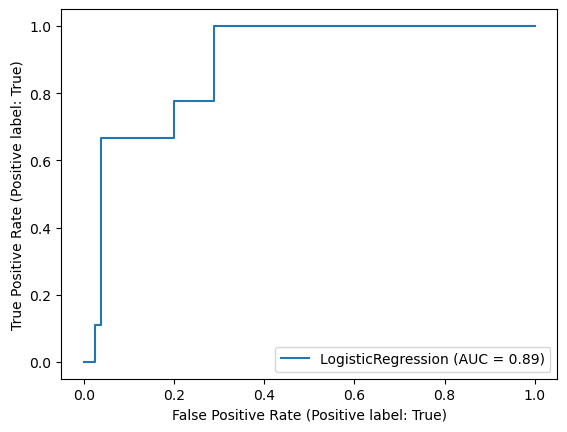

In [44]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logistic_classifier, X_test, y_test)

Ok, what did this all mean?  Well accuracy may jump out at 91%, but that is deceivingly high.  That includes its prediction for all players, mvp and non-mvp.

For the 1.0 class, that we care about \
\
Precision = (# actual Finals MVPs predicted to be Finals MVP) / (# predicted Finals MVPs) \
\
Recall = (# actual Finals MVPs predicted to be Finals MVP) / (# actual Finals MVPs) 


So what we care about above is recall, being able to label Finals MVPs. \
\
So on my latest run of this model, I got 82% accuracy (yours likely will differ each time you rerun), so not perfect but better than our "quick and dirty" model.

What is that 18% we're missing?  And how does it compare to those we missed with our simplified approach? Well let's take a look.

In [219]:
print("Our quick and dirty mistakes")
mistakes = ppg_trb_ast_output[ppg_trb_ast_output['Correct']== False]
mistakes = pd.merge(mistakes, output, on=['Year','Player'], how='left')
mistakes = mistakes.drop(columns=['Team_y','Correct_y','Binary','mvp','MVP'])
mistakes.columns = ['Year', 'Team', 'MVP', 'Guess', 'Correct?',
       'prob_mvp','rank']
mistakes

Our quick and dirty mistakes


,Year,Team,MVP,Guess,Correct?,prob_mvp,rank
0,2024,Boston Celtics,Jaylen Brown,Jayson Tatum,False,0.01,3
1,2015,Golden State Warriors,Andre Iguodala,Stephen Curry,False,0.78,2
2,2014,San Antonio Spurs,Kawhi Leonard,Tim Duncan,False,0.83,1
3,2008,Boston Celtics,Paul Pierce,Kevin Garnett,False,0.74,1
4,2007,San Antonio Spurs,Tony Parker,Tim Duncan,False,0.70,1
5,2004,Detroit Pistons,Chauncey Billups,Richard Hamilton,False,0.96,1
6,1988,Los Angeles Lakers,James Worthy,Magic Johnson,False,0.07,2
7,1981,Boston Celtics,Cedric Maxwell,Larry Bird,False,0.99,1
8,1980,Los Angeles Lakers,Magic Johnson,Kareem Abdul-Jabbar,False,0.96,2
9,1979,Seattle SuperSonics,Dennis Johnson,Gus Williams,False,0.11,3


In [220]:
print("A handful of our ML mistakes")
ml_mistakes = output[(output['Correct']== False)].reset_index(drop=True)
ml_mistakes.to_csv('output/machine_learning_mistakes.csv')
ml_mistakes.sample(5)

A handful of our ML mistakes


,Year,Team,MVP,Player,mvp,prob_mvp,Rank,Binary,Correct
36,1973,New York Knicks,Willis Reed,Walt Frazier,False,0.93,1,1.0,False
24,1982,Los Angeles Lakers,Magic Johnson,Magic Johnson,True,0.14,1,0.0,False
16,1998,Chicago Bulls,Michael Jordan,Michael Jordan,True,0.06,3,0.0,False
39,1970,New York Knicks,Willis Reed,Willis Reed,True,0.00,3,0.0,False
13,2005,San Antonio Spurs,Tim Duncan,Manu GinÃ³bili,False,0.97,1,1.0,False


So while our accuracy is not 100%, we have to consider, that 100% may not be the goal.  Because we are not fitting to a perfectly labeled dataset.  The voters could be wrong.

So where does that leave us?  Well I'm a little surprised by some divergences from our model to the labels.  \
\
I'm also surprised by the lack of divergence on some specific examples *cough* Andre Iguodala 2015 *cough* (on some model runs he gets flagged, others not)

### Visualizations

We're going to pull the logos for each of these teams to add a little wow to our terminal visualization.

In [223]:
picks = output[(output['Binary']== 1) | (output['mvp']== 1)].reset_index(drop=True)
visual = picks.drop(columns=['Binary'])
visual['logo_url'] = visual.apply(lambda x: logo_from_team_name(x['Team'],x['Year']),axis=1)
visual.to_csv('output/tableau_winners_and_picks.csv')
visual

,Year,Team,MVP,Player,mvp,prob_mvp,Rank,Correct,logo_url
0,2024,Boston Celtics,Jaylen Brown,Jayson Tatum,False,0.86,1,False,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
1,2024,Boston Celtics,Jaylen Brown,Jaylen Brown,True,0.01,3,False,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
2,2023,Denver Nuggets,Nikola Jokic,Nikola Jokic,True,0.72,1,True,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
3,2023,Denver Nuggets,Nikola Jokic,Jamal Murray,False,0.64,2,False,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
4,2022,Golden State Warriors,Stephen Curry,Stephen Curry,True,0.85,1,True,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
...,...,...,...,...,...,...,...,...,...
81,1971,Milwaukee Bucks,Kareem Abdul-Jabbar,Kareem Abdul-Jabbar,True,1.00,1,True,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
82,1971,Milwaukee Bucks,Kareem Abdul-Jabbar,Oscar Robertson,False,0.69,2,False,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
83,1970,New York Knicks,Willis Reed,Willis Reed,True,0.00,3,False,https://cdn.ssref.net/req/202407241/tlogo/bbr/...
84,1970,New York Knicks,Willis Reed,Walt Frazier,False,0.99,1,False,https://cdn.ssref.net/req/202407241/tlogo/bbr/...


If you want to embed each image into the df, you can do so, with the below commented out code.

In [189]:
# visual['logo'] = visual['logo_url'].apply(lambda x: fetch_image(x,name_img(x)))
# a = fetch_image(visual['logo'][4],name_img(visual['logo'][4]))

## Conclusion

This was a lot of fun!

### Next Steps

1. Look at players based on gross counting statistics, and not their relative rank among teammates (data is already prepared! see full_top_8_unranked).csv
2. Create a slightly adapted model to attribute finals MVP share amongst teammates each year, in the way that the MVP regular season award does.


3. Push the existing logistic model further - SMOTE is a good start, but there are many other optimizations I can tinker with.  Good places to start could be on try other remedies to imbalanced data, changing the number of k fold validation
4. Try other ML models!  Decision trees, Random Forest, among others would be fun to play around with this data.
5. Visualize some of the findings!  Nothing is more fun than looking at a nicely formatted Tableau table.